<a href="https://colab.research.google.com/github/DivyaSwamy/transformers_tutorials/blob/main/access_datasets_huggingface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### ***Author - Divya Swaminathan***
##### ***Date - August 2025***
---

### **Goals** -
> In this tutorial we will load vision datasets from huggingface and explore them.

**Step1**  - Generate a token by logging into Hugging face (optional but recommended)
  * Login to HF,
  * Navigate to access tokens, generate token for google colab,
  * On your google colab notebook open secrets key on the left panel and paste copied token.

**Step2** -
  * We will load & explore a dataset in the process learning the how datasets works within huggingface.
    * Navigate to the huggingface portal, search for relevant datasets and copy path to dataset. One can use this to access the dataset from huggingface.
    * I have chosen "Aliounethegoat/classification-medicale-multi-cancer" for this tutorial
    
**Step3**
  * Excercise - load and explore an EHR dataset
  * "QuirkyDataScientist/synthetic_ehr_dataset_part_5"


> Install transformers and datasets

In [1]:
%pip install -q transformers
%pip install -U datasets[vision]

# use %pip install -U datasets to access all datasets in Huggingface.
# datasets[vision] -one is only accessing vision datasets

> The following bit of code checks for the huggingface token.

In my notebook, under settings, the token is saved under the name 'huggingface_token'.
If this name is changed, correspondingly the ***userdata.get(name)*** will change.

In [2]:
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('huggingface_token') # Retrieve the token from secrets

if HF_TOKEN:
  login(HF_TOKEN)
  print("Successfully logged in to Hugging Face!")
else:
  print("Hugging Face token not found in Colab Secrets.")


Successfully logged in to Hugging Face!


In [3]:
from datasets import load_dataset_builder, load_dataset
from datasets import  get_dataset_split_names, DatasetDict, Dataset



* One can navigate to the huggingface portal, search for relevant datasets and copy path to dataset. One can use this to access the dataset from huggingface.

* *`load_dataset_builder(path_to_dataset)`* - use function to load a dataset builder and inspect a dataset’s attributes without committing to downloading it:

* For every dataset you can check it's *info* (description of dataset) and *features* (what's in it, images, labels etc.) and *splits* (train, test, validate) fields.


In [4]:
path_to_dataset = "Aliounethegoat/classification-medicale-multi-cancer"
#path_to_dataset = "cornell-movie-review-data/rotten_tomatoes"

ds_builder = load_dataset_builder(path_to_dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/367 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

* *`ds_builder = load_dataset_builder(path_to_dataset)`* , here you will get a warning if you are logged out of your hugging face account. Once logged in the warning disappears.


* If you are happy with the dataset use function *`load_dataset()`* to download dataset.


In [42]:
# for ds_builder there are 2 main features - description and features.

print(ds_builder.info.description)
print('-------')
print(ds_builder.info.features)
print('-------')
print(ds_builder.info.splits)



-------
{'image': Image(mode=None, decode=True), 'label': Value('string'), 'label_name': Value('string')}
-------
{'train': SplitInfo(name='train', num_bytes=10176400979.75, num_examples=130002, shard_lengths=None, dataset_name=None)}


In [7]:
for elem in ds_builder.info.features:
  print(elem, ':-',ds_builder.info.features[elem] )

image :- Image(mode=None, decode=True)
label :- Value('string')
label_name :- Value('string')


In [8]:
# Load the dataset
dataset = load_dataset(path_to_dataset)
print('---------')
dataset

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

data/train-00000-of-00021.parquet:   0%|          | 0.00/643M [00:00<?, ?B/s]

data/train-00001-of-00021.parquet:   0%|          | 0.00/604M [00:00<?, ?B/s]

data/train-00002-of-00021.parquet:   0%|          | 0.00/541M [00:00<?, ?B/s]

...

data/train-00020-of-00021.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/130002 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/21 [00:00<?, ?it/s]

---------


DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 130002
    })
})

In [9]:
# Only training set with 130002 images.
# Each image has a label & label_name associated with it.
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 130002
    })
})

In [10]:
# If the DatasetDict is such that it has train, test and validate datasets here
# the output of this command would be a list stating the same.
get_dataset_split_names(path_to_dataset)

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

['train']

In [11]:
print( dataset['train'][0])
print(dataset['train'][1500])
print(dataset['train'][13000])

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224 at 0x7AF07D9428D0>, 'label': 'colon_bnt', 'label_name': 'cancer_poumon_colon'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224 at 0x7AF07D9427B0>, 'label': 'colon_bnt', 'label_name': 'cancer_poumon_colon'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224 at 0x7AF07D943050>, 'label': 'lung_aca', 'label_name': 'cancer_poumon_colon'}




* What is the difference b/w label and label_name?

The dataset has images from various cancer types. Label_names labels cancer type. Label is the sub classification for a cancer type. Without a datadict, it's unclear what each sub classification refers to

In [12]:
from collections import defaultdict

count_label_names = defaultdict(int)
count_label = defaultdict(int)

for item in dataset['train']['label']:
  count_label[item]+= 1

for item in dataset['train']['label_name']:
  count_label_names[item]+= 1


In [13]:
count_label

defaultdict(int,
            {'colon_bnt': 5000,
             'colon_aca': 5000,
             'lung_aca': 5000,
             'lung_scc': 5000,
             'lung_bnt': 5000,
             'breast_benign': 5000,
             'breast_malignant': 5000,
             'lymph_mcl': 5000,
             'lymph_cll': 5000,
             'lymph_fl': 5000,
             'kidney_tumor': 5000,
             'kidney_normal': 5000,
             'oral_normal': 5001,
             'oral_scc': 5001,
             'cervix_mep': 5000,
             'cervix_pab': 5000,
             'cervix_sfi': 5000,
             'cervix_dyk': 5000,
             'cervix_koc': 5000,
             'all_pro': 5000,
             'all_benign': 5000,
             'all_pre': 5000,
             'all_early': 5000,
             'brain_menin': 5000,
             'brain_glioma': 5000,
             'brain_tumor': 5000})

In [14]:
count_label_names

defaultdict(int,
            {'cancer_poumon_colon': 25000,
             'cancer_sein': 10000,
             'lymphome': 15000,
             'cancer_rein': 10000,
             'cancer_bouche': 10002,
             'cancer_col_uterus': 25000,
             'Leucémie aiguë lymphoblastique': 20000,
             'cerveau': 15000})

##### Can you isolate all the breast cancer images !!

Yes.

* dataset['train'][25000:35000] is also viable though slow.


In [15]:
# This logic runs very slowly
breast_cancer = dataset['train'].filter(lambda x: x['label_name'] == 'cancer_sein')


Filter:   0%|          | 0/130002 [00:00<?, ? examples/s]

In [16]:
breast_cancer

Dataset({
    features: ['image', 'label', 'label_name'],
    num_rows: 10000
})

In [17]:
print(breast_cancer[500])
print(breast_cancer[-500])

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224 at 0x7AF07E7FCD40>, 'label': 'breast_benign', 'label_name': 'cancer_sein'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224 at 0x7AF07E7D57F0>, 'label': 'breast_malignant', 'label_name': 'cancer_sein'}


In [ ]:
#next(iter(vision_dataset['train']))

> Let's plot a random section of images from breast_cancer dataset

In [18]:
from PIL import Image
import random
import matplotlib.pyplot as plt
import numpy as np

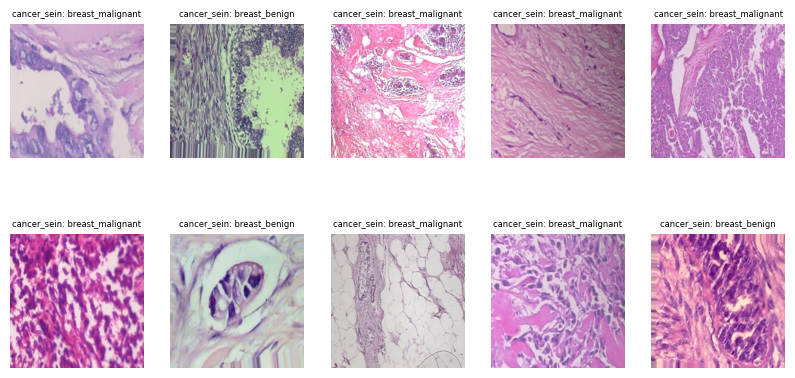

In [19]:
idx = [random.randint(0, 10000) for i in range(10)]

fig, axs = plt.subplots(2,5, figsize = (10,5))
axs = axs.ravel()

for i in range(10):
  j = idx[i]
  image_np = np.array(breast_cancer[j]['image'])
  pil_image = Image.fromarray(image_np)
  # print('Image Dimensions', image_np.shape, pil_image.size)
  axs[i].imshow(image_np)
  axs[i].set_title(breast_cancer[j]['label_name'] +': '
         + breast_cancer[j]['label'], fontsize = 6)
  axs[i].set_axis_off()


In [20]:
# Is it a balanced dataset?

count_label = defaultdict(int)

for item in breast_cancer['label']:
  count_label[item]+= 1

print(count_label)

defaultdict(<class 'int'>, {'breast_benign': 5000, 'breast_malignant': 5000})


> Using iterable datasets -> convert dataset on to iteratable dataset and explore

 *` There are two types of dataset objects, a Dataset and an IterableDataset. Whichever type of dataset you choose to use or create depends on the size of the dataset. In general, an IterableDataset is ideal for big datasets (think hundreds of GBs!) due to its lazy behavior and speed advantages, while a Dataset is great for everything else. This page will compare the differences between a Dataset and an IterableDataset to help you pick the right dataset object for you.`*

 > Since breast_cancer is a subset of ds, it wasn't necessary to use iterable_dataset here. Neverthless good for practise.

In [21]:
iterable_bc = breast_cancer.to_iterable_dataset()

Text(0.5, 1.0, 'breast_benign')

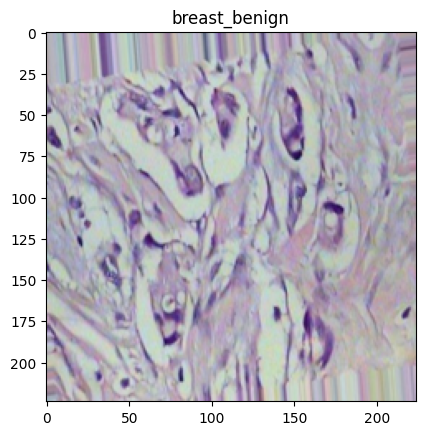

In [41]:
x = next(iter(breast_cancer.shuffle())) # try this what happens if you use x = next(iter(breast_cancer))

image_np = np.array(x['image'])
pil_image = Image.fromarray(image_np)
plt.imshow(pil_image)
plt.title(x['label'])



For an iterable dataset, use .shuffle() to shuffle images.
  * .take() can be used to extract a specific image id.
  * using list with .take() will list the number of images specified within .take(). The larger this number the longer it takes for the program to list all images.



In [43]:

list(breast_cancer.shuffle().take(5))


[{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224>,
  'label': 'breast_benign',
  'label_name': 'cancer_sein'},
 {'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224>,
  'label': 'breast_malignant',
  'label_name': 'cancer_sein'},
 {'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224>,
  'label': 'breast_malignant',
  'label_name': 'cancer_sein'},
 {'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224>,
  'label': 'breast_benign',
  'label_name': 'cancer_sein'},
 {'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224>,
  'label': 'breast_malignant',
  'label_name': 'cancer_sein'}]

In [40]:
# using .take you are accessing a single image from the dataset.
breast_cancer.take(1000)

Dataset({
    features: ['image', 'label', 'label_name'],
    num_rows: 1000
})